In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from astroML.plotting import setup_text_plots
import math

In [ ]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS
x = z_sample
y = mu_sample
X_new = np.reshape(np.linspace(0, 2, 100), [100, 1])


#shuffle 2 arrays in the same way
from sklearn.utils import shuffle
x, y = shuffle(x, y, random_state=0)

#divide array by 3
n = math.floor(len(x)/3)

x_noise = x[:n]
y_noise = y[:n]

x_cv = x[-n:]  #sometimes it loses a point
y_cv = y[-n:]




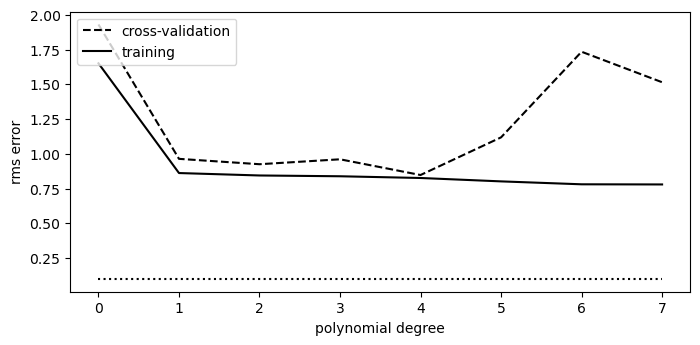

In [24]:
d = np.arange(0, 8)

training_err = np.zeros(d.shape)
crossval_err = np.zeros(d.shape)

fig = plt.figure(figsize=(8, 8))
for i in range(len(d)):
    p = np.polyfit(x_noise, y_noise, d[i])
    training_err[i] = np.sqrt(np.sum((np.polyval(p, x_noise) - y_noise) ** 2)
                              / len(y_noise))
    crossval_err[i] = np.sqrt(np.sum((np.polyval(p, x_cv) - y_cv) ** 2)
                              / len(y_cv))

BIC_train = np.sqrt(len(y_noise)) * training_err + d * np.log(len(y_noise))
BIC_crossval = np.sqrt(len(y_noise)) * crossval_err + d * np.log(len(y_noise))

ax = fig.add_subplot(211)
ax.plot(d, crossval_err, '--k', label='cross-validation')
ax.plot(d, training_err, '-k', label='training')
ax.plot(d, 0.1 * np.ones(d.shape), ':k')

#ax.set_xlim(0, 14)
#ax.set_ylim(0, 0.8)

ax.set_xlabel('polynomial degree')
ax.set_ylabel('rms error')
ax.legend(loc=2)

#ax = fig.add_subplot(212)
#ax.plot(d, BIC_crossval, '--k', label='cross-validation')
#ax.plot(d, BIC_train, '-k', label='training')

#ax.legend(loc=2)
#ax.set_xlabel('polynomial degree')
#ax.set_ylabel('BIC')

plt.show()